# Entendendo o Negócio

## 🤖☕ Entendendo o Negócio

### 📋 Contexto do Projeto

Decidi abrir uma pequena cafeteria com **garçons robôs** em Los Angeles. É um projeto bem promissor, mas caro, então eu e meus parceiros decidimos tentar atrair investidores. 

Eles estão interessados nas **condições atuais do mercado** e querem saber se conseguirei manter meu sucesso quando a novidade de garçons robôs esmorecer.

### 🎯 Objetivo da Análise

Sou um guru de análise, então meus parceiros me pediram para preparar uma **pesquisa do mercado**. Tenho dados de código aberto sobre restaurantes em LA.

### 📊 Dados Disponíveis

- **Dataset**: Informações sobre restaurantes em Los Angeles
- **Fonte**: Dados de código aberto
- **Finalidade**: Análise de mercado para atrair investidores

- **Tabelas que utilizarei:** 
  
     Tabela **rest_data**:  Cada linha representa um estabelecimento único com suas características específicas como nome, endereço, se faz parte de uma rede, tipo de estabelecimento e número de assentos.

| Colunas      | Significado                           | Descrição |
|--------------|---------------------------------------|----------------|
| object_name  | Nome do estabelecimento               | Um mesmo nome pode está em mais de uma linha |
| chain        | Estabelecimento de rede (TRUE/FALSE)  | Nenhum estabelecimento pode ser de rede e não de rede, nem que seja em endereços diferentes |
| object_type  | Tipo de estabelecimento               | Um estabelecimento pode ofertar mais de um tipo de serviço, como o McDonald's |
| address      | Endereço                              |               --                              |
| number       | Número de assentos | Quantas pessoas podem ser atendidas simultaneamente, no máximo |

### 🔍 Questões-Chave a Investigar

- Como está o mercado atual de restaurantes em LA?
- Quais são as tendências e padrões do setor?
- Qual o potencial de sucesso para minha cafeteria inovadora?
- Como me posicionar competitivamente no mercado?


# 1. Bibliotecas e funções usadas

## 1.1. Bibliotecas:

In [1]:
import pandas as pd
import plotly.express as px
import seaborn as sns
from matplotlib import pyplot as plt
from scipy import stats as st
import numpy as np
import re

## 1.1. Funções que utilizarei:

### - Função **percent_duplicated**: Percentual de valores duplicados impliscitos

In [2]:
def percent_duplicated(df):
    '''
    Essa função recebe um dataframe e retorna uma tabela com o percentual de valores duplicados em cada coluna comparado 
    ao número de linhas total do dataframe, onde as colunas desse dataframe são as colunas de df e o percentual de
    duplicados em cada uma (numa escala de 0% a 100%).
    '''
    dicionario = {}
    for col in df.columns:
        dicionario[col] = [100 * (df[col].duplicated().sum() / df.shape[0]).round(3)] 

    df_return = pd.DataFrame(dicionario)
    df_return = df_return.T.reset_index()
    df_return.columns = ['colunas', 'percentual_de_duplicados']

    return df_return

### - Função **teste_dados_continuos**: Faz um teste de hipóteses entre a igualdade das médias de duas variáveis contínuas

In [3]:
def teste_dados_continuos(metrica_A, metrica_B, h_0: str, h_1: str, significancia: float = 0.05):
    '''
    Analisa normalidade (Shapiro ou Anderson-Darling), homogeneidade de variância (Levene) e decide entre:
    - T-test (Student ou Welch) se normal.
    - Mann-Whitney se não normal.

    OBS: Usa Shapiro-Wilk para N < 5000 e Anderson-Darling para N >= 5000.

     INPUTS:
    metrica_A: Métrica contínua usada no grupo A (Ex.: Média, Valor bruto, Valor acumulado, etc...) -> DataFrame
    metrica_B: Métrica contínua usada no grupo B (Ex.: Média, Valor bruto, Valor acumulado, etc...) -> DataFrame
    h_0: Hipótese nula -> 'str'
    h_1: Hipótese alternativa -> 'str'
    significancia: Nivel de significancia estatistica usado - entre 0 e 1 (Definido 0.05 como padrão) -> 'float'
    '''
    
    # 1. Limpeza e Preparação (Garante que sejam Series para usar dropna)
    a = pd.Series(metrica_A).dropna()
    b = pd.Series(metrica_B).dropna()
    
    def checar_normalidade(dados, nome_grupo):
        n = len(dados)
        if n < 5000:
            stat, p = st.shapiro(dados)
            is_normal = p > significancia
            print(f"Shapiro-Wilk ({nome_grupo}): p={p:.5f} | Normal: {is_normal}")
            return is_normal
        else:
            # Anderson-Darling retorna estatística e valores críticos
            res = st.anderson(dados, dist='norm')
            # res.critical_values[2] corresponde ao nível de 5% (0.05)
            # Se a estatística for MENOR que o valor crítico, não rejeitamos a normalidade
            is_normal = res.statistic < res.critical_values[2] 
            print(f"Anderson-Darling ({nome_grupo}): Stat={res.statistic:.3f}, Crit(5%)={res.critical_values[2]} | Normal: {is_normal}")
            return is_normal

    normal_A = checar_normalidade(a, "Grupo A")
    normal_B = checar_normalidade(b, "Grupo B")

    # 2. Decide qual teste usar baseado na Normalidade E Variância
    if normal_A and normal_B:
        # DADOS NORMAIS -> Verificar Variância (Levene)
        levene_stat, p_levene = st.levene(a, b)
        variancias_iguais = p_levene > significancia
        
        print(f"Variância (Levene): p={p_levene:.5f} (Iguais: {variancias_iguais})")
        
        # Executa Teste t (Student se var iguais, Welch se diferentes)
        t_stat, p_value = st.ttest_ind(a, b, equal_var=variancias_iguais)
        tipo_teste = "Teste t de Student" if variancias_iguais else "Teste t de Welch"
    else:
        # DADOS NÃO NORMAIS -> Mann-Whitney
        u_stat, p_value = st.mannwhitneyu(a, b, alternative='two-sided')
        tipo_teste = "Mann-Whitney"

    print(f"Decisão: Usando {tipo_teste}")

    # 3. Resultado Final
    print("\n--- Resultado do Teste de Hipótese ---")
    print(f"P-valor: {p_value:.4f} | Alpha: {significancia}")
    
    if p_value < significancia:
        resultado = f"❌ Rejeitamos H0: {h_1}"
    else: 
        resultado = f"✅ Mantemos H0: {h_0}"
    
    print(resultado)

### - Função **extrair_rua**: Recebe um endereço de um estabelecimento em Los Angeles e retorna o nome da rua daquele endereço, através do regex.

In [4]:
def extrair_rua(address):
    '''
    Essa função Recebe um endereço de um estabelecimento em Los Angeles e retorna o nome da rua daquele endereço, através do regex.
    '''
    # 1. Padronização inicial
    res = str(address).strip().upper()
    
    # 2. Remove o número do imóvel no início
    res = re.sub(r'^\d+\s+', '', res)
    
    # 3. Remove frações de endereço (ex: 1/2)
    res = res.replace("1/2 ", "")
    
    # 4. Remove pontos cardeais no início (N, S, E, W, NORTH, SOUTH, EAST, WEST)
    res = re.sub(r'^([NSEW]|NORTH|SOUTH|EAST|WEST)\s+', '', res)
    
    # 5. Remove complementos (STE, UNIT, #, etc.) e o que vier depois
    res = re.sub(r'\s+(STE|UNIT|SUITE|#|BLDG|FL|RM|PLZ|SHOP|A-B|LOWR|UPPR|BOX).*$', '', res, flags=re.IGNORECASE)

    # 6. Remove números isolados no final (preservando ordinais como 6TH, 2ND)
    res = re.sub(r'\s+(?!\d+(ST|ND|RD|TH))\d+$', '', res)
    
    return res.strip()


# 2. Importação e Preparação dos dados para a Análise

## 2.1. Otimizando os dados para importa-los

In [5]:
# Carregando uma pequena amostra de 100 linhas dos dados para otimiza-los, com o parâmetro 'nrows':
rest_data_test = pd.read_csv('../datasets/rest_data_us_upd.csv', nrows = 100)

rest_data_test.info(memory_usage = 'deep') # Observando as informações gerais e a memória usada

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   id           100 non-null    int64 
 1   object_name  100 non-null    object
 2   address      100 non-null    object
 3   chain        100 non-null    bool  
 4   object_type  100 non-null    object
 5   number       100 non-null    int64 
dtypes: bool(1), int64(2), object(3)
memory usage: 20.4 KB


In [6]:
# vamos verificar se 'object_type' é uma coluna categórica:
rest_data_test['object_type'].unique()

array(['Cafe', 'Restaurant', 'Fast Food', 'Bakery', 'Bar', 'Pizza'],
      dtype=object)

In [7]:
# Temos uma coluna categórica, vamos converte-la para seu tipo apropriado afim de nos 
# livrarmos de dados do tipo object, que consomem muita memória:

rest_data_test['object_type'] = rest_data_test['object_type'].astype('category')

rest_data_test.info(memory_usage = 'deep') 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   id           100 non-null    int64   
 1   object_name  100 non-null    object  
 2   address      100 non-null    object  
 3   chain        100 non-null    bool    
 4   object_type  100 non-null    category
 5   number       100 non-null    int64   
dtypes: bool(1), category(1), int64(2), object(2)
memory usage: 15.3 KB


conclusão:

de 22.8 kb para 16.9 kb. Conseguimos otimizar os nossos dados em 25%, mas não dar pra fazer mais nada além disso. 

## 2.2. Importando os dados

In [8]:
# Importando os dados completos com as colunas otimizadas: A coluna object_type é do tipo categórica,
# e a coluna chain é do tipo booleana (o formato 'boolean' é ideal quando se tem valores nulos)
rest_data = pd.read_csv('../datasets/rest_data_us_upd.csv', dtype = {'object_type':'category',
                                                                  'chain':'boolean'})

In [9]:
# Imprimindo uma amostra dos dados:
rest_data.sample(5)

,id,object_name,address,chain,object_type,number
4743,16529,NOODLE 24,301 S WESTERN AVE 104,False,Restaurant,8
6696,18482,"JANCHIJIP, INC.",3328 W 8TH ST,False,Restaurant,36
6992,18778,FIVE GUYS BURGERS & FRIES #1394,530 W 27TH ST 104,False,Fast Food,97
9437,21223,BBCM,835 W JEFFERSON BLVD 7F 7G,False,Restaurant,47
1438,13224,CABBAGE PATCH,520 W 6TH ST,True,Restaurant,110


In [10]:
# Imprimindo as informações gerais dos dados
rest_data.info(memory_usage = 'deep')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9651 entries, 0 to 9650
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   id           9651 non-null   int64   
 1   object_name  9651 non-null   object  
 2   address      9651 non-null   object  
 3   chain        9648 non-null   boolean 
 4   object_type  9651 non-null   category
 5   number       9651 non-null   int64   
dtypes: boolean(1), category(1), int64(2), object(2)
memory usage: 1.4 MB


## 2.3. Preparando os dados para a análise

### 2.3.1. Valores ausentes

In [11]:
# verificando os valores nulos:
rest_data.isna().sum()

id             0
object_name    0
address        0
chain          3
object_type    0
number         0
dtype: int64

Temos 3 valores nulos em 'chain'. Como são poucos valores e estamos analisando os negócios franquiados e não franquiados, então podemos remove-los.

In [12]:
rest_data = rest_data.dropna()

### 2.3.2. Valores duplicados impliscitos e expliscitos:

#### (I). analisando os duplicados expliscitos:

In [13]:
# verificando linhas completamente duplicadas:
linhas_duplicadas = rest_data.duplicated().sum()

print(f'Boa notícia: Temos {linhas_duplicadas} linhas completamente duplicadas.')

Boa notícia: Temos 0 linhas completamente duplicadas.


#### (II). analisando os duplicados impliscitos:

In [14]:
# Aplicando a função percent_duplicated no nosso dataframe rest_data:
percent_duplicated(rest_data)

,colunas,percentual_de_duplicados
0,id,0.0
1,object_name,10.1
2,address,11.8
3,chain,100.0
4,object_type,99.9
5,number,97.8


conclusão:

Ainda não identificamos nenhum problema óbvio de duplicados, mas suspeitamos de problemas em estabelecimentos duplicados (onde temos 10,1% de dados duplicados). vamos dar uma olhada mais de perto:

#### (III). analisando outros problemas de duplicados impliscitos:

##### **- Vamos verificar se existe estabeleciento franquiado e não franquiado ao mesmo tempo e vamos remove-los (isso é um problema de dados)**

In [15]:
estabelecimentos_e_franquias = rest_data.groupby('object_name')['chain'].nunique().sort_values(ascending=False).reset_index()

estabelecimentos_e_franquias.head(3)

,object_name,chain
0,FLAME BROILER,2
1,EL SUPER,2
2,MARTHA'S KITCHEN,2


In [16]:
franquia_e_nao = estabelecimentos_e_franquias[estabelecimentos_e_franquias['chain'] == 2]['object_name']

print(f'conclusão:\n \nTemos um grande problema: {len(franquia_e_nao)} estabelecimentos estão listados como de rede e não de rede ao mesmo tempo.\n \n São eles: \n \n{franquia_e_nao.to_list()}')

conclusão:
 
Temos um grande problema: 7 estabelecimentos estão listados como de rede e não de rede ao mesmo tempo.
 
 São eles: 
 
['FLAME BROILER', 'EL SUPER', "MARTHA'S KITCHEN", 'NORDSTROM', 'SOUTHERN CALIFORNIA PIZZA CO LLC', 'SPROUTS FARMERS MARKET', "WETZELS PRETZEL'S"]


In [17]:
# Devemos remover esses estabelecimentos problemáticos:
rest_data = rest_data[~rest_data['object_name'].isin(franquia_e_nao)]

##### **- Vamos verificar se cada estabelecimento está fazendo apenas um único tipo de negócio ou não:**

In [18]:
estabelecimentos_e_negocios = rest_data.groupby('object_name')['object_type'].nunique().sort_values(ascending=False).reset_index()

estabelecimentos_e_negocios.head(3)

,object_name,object_type
0,MCDONALD'S,2
1,TARGET,2
2,WHOLE FOODS MARKET,2


In [19]:
dois_negocios = estabelecimentos_e_negocios[estabelecimentos_e_negocios['object_type'] == 2]['object_name']

print(f'{len(dois_negocios)} estabelecimentos estão fazendo 2 negócios ao mesmo tempo.\n \n São eles: \n \n{dois_negocios.to_list()}')

3 estabelecimentos estão fazendo 2 negócios ao mesmo tempo.
 
 São eles: 
 
["MCDONALD'S", 'TARGET', 'WHOLE FOODS MARKET']


conclusão: 

Ter 2 tipos de negócio é natural. Nada para tratar aqui. Mas o ponto positivo é que temos uma visão mais detalhada de quem está expandindo para outros tipos de negócio. Para a surpresa de ninguém, o McDonald's tem mais de um tipo de negócio no setor alimentício.

### 2.3.3. conclusões e principais achados do pré-processamento de dados:

- Removemos 3 linhas de estabelecimentos com valores de rede ausentes
- Removemos 7 estabelecimentos que estavam com dados problemáticos (Listados como de rede e não de rede ao mesmo tempo)
- "MCDONALD'S", 'WHOLE FOODS MARKET' e 'TARGET' são os estabelecimentos com mais de um tipo de negócio no setor alimentício da região de L.A.

# 3. Análise dos Dados

## 3.1. Investigando as proporções de vários tipos de estabelecimentos.

In [20]:
# Vamos agrupar o 'id' por 'object_type' para encontrar a quantidade de estabelecimentos por tipo, e depois calcular a proporção de cada
# tipo com relação ao total de estabelecimentos:

estabelecimentos_por_tipo = rest_data.groupby('object_type')['id'].count().reset_index().rename(columns={'object_type':'tipo', 'id':'quantidade_de_estabelecimentos'})

total = rest_data.shape[0]

estabelecimentos_por_tipo['proporcao_percent'] = (100 * estabelecimentos_por_tipo['quantidade_de_estabelecimentos']/total).round(2)

estabelecimentos_por_tipo

C:\Users\Z4r4k1\AppData\Local\Temp\ipykernel_22332\1102814823.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  estabelecimentos_por_tipo = rest_data.groupby('object_type')['id'].count().reset_index().rename(columns={'object_type':'tipo', 'id':'quantidade_de_estabelecimentos'})


,tipo,quantidade_de_estabelecimentos,proporcao_percent
0,Bakery,283,2.94
1,Bar,292,3.03
2,Cafe,434,4.51
3,Fast Food,1066,11.07
4,Pizza,317,3.29
5,Restaurant,7238,75.16


C:\Users\Z4r4k1\AppData\Local\Temp\ipykernel_22332\3137669041.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


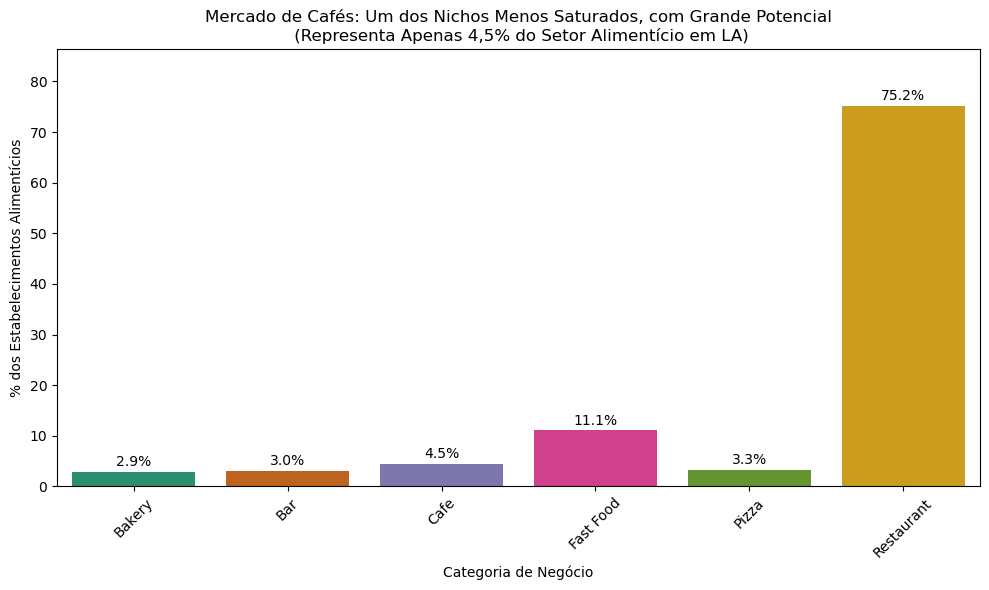

In [21]:
# Construindo um gráfico de barras para avaliar o resultado:


plt.figure(figsize=(10, 6))

# Criando o gráfico de barras com a paleta "Dark2"
ax = sns.barplot(
    x='tipo', 
    y='proporcao_percent', 
    data=estabelecimentos_por_tipo, 
    palette="Dark2"
)

# adicionando os % de cada barra:

for p in ax.patches:

    ax.annotate(f'{p.get_height():.1f}%', 

                (p.get_x() + p.get_width() / 2., p.get_height()), 

                ha='center', va='center', 

                xytext=(0, 7), 

                textcoords='offset points')



plt.title('Mercado de Cafés: Um dos Nichos Menos Saturados, com Grande Potencial\n (Representa Apenas 4,5% do Setor Alimentício em LA)')

plt.xlabel('Categoria de Negócio')

plt.ylabel('% dos Estabelecimentos Alimentícios')

plt.xticks(rotation=45)

plt.ylim(0, estabelecimentos_por_tipo['proporcao_percent'].max() * 1.15) # Para impedir que os dados menores fiquem dificeis de visualizar

plt.tight_layout()

plt.show()

conclusão:

- **Restaurantes dominam:** 75.16% do mercado (mostrando-se um possivel nicho muito saturado)
- **Fast Food:** 11.07% (segundo lugar)
- **Café:** apenas 4.51% (Nossa área de interesse!)
- Oportunidade: Mercado de cafés é o menos saturado (um ponto positivo para os investidores, é quase um oceano azul na região)

## 3.2. Investigando as proporções de estabelecimentos que fazem parte ou não de uma rede.

In [22]:
# Calculando a quantidade dos estabelecimentos que fazem parte ou não de uma rede:
rede = rest_data.groupby('chain')['id'].count().reset_index().rename(columns = {'chain':'sao_de_rede_ou_nao', 'id':'quantidade'})

rede

,sao_de_rede_ou_nao,quantidade
0,False,5963
1,True,3667


In [23]:
# Construindo um grafico de setores para mostrar a proporção percentual dos estabelecimentos que fazem parte ou não de uma rede:

# Criando uma cópia para não alterar o DataFrame original
df_plot = rede.copy()

# Convertendo os valores da coluna para Strings e depois mapeamos
# Isso evita o erro de tipo (Boolean vs String)
category_map = {False: 'Independente', True: 'De Rede', 'false': 'Independente', 'true': 'De Rede'}
df_plot['sao_de_rede_ou_nao'] = df_plot['sao_de_rede_ou_nao'].map(category_map)

# Criando o gráfico
fig = px.pie(
    df_plot, 
    values='quantidade', 
    names='sao_de_rede_ou_nao', 
    title='Os Estabelecimentos Alimentícios em L.A. São Majoritariamente Independentes',
    color_discrete_sequence=px.colors.qualitative.Dark2,
    hole=0.3 # Um leve efeito de rosca para modernizar
)

# Personalizando os rótulos
fig.update_traces(
    textinfo='percent+label',
    textposition='inside',
    marker=dict(line=dict(color='#FFFFFF', width=2))
)

# Ajustando o layout
fig.update_layout(
    title_x=0.5,
    margin=dict(l=20, r=20, t=60, b=20)
)

fig.show()

conclusão:
- Aproximadamente 62% são estabelecimentos independentes (não fazem parte de rede)
- Aproximadamente 38% são estabelecimentos de rede (franquias/redes)
- Essa análise mostra que há espaço para estabelecimentos independentes em LA (62% do mercado), o que é positivo para a nossa cafeteria inovadora.


## 3.3. Qual tipo de estabelecimento é típico para redes?

In [24]:
# vamos filtrar os dados de rede para responder essa pergunta:
de_rede = rest_data[rest_data['chain'] == True]

# Agora, vamos descobrir os tipos de negócio mais escolhidos para redes, analisando sua proporção:

de_rede_por_tipo = de_rede.groupby('object_type')['id'].count().reset_index().rename(columns={'object_type':'tipo', 'id':'quantidade_de_estabelecimentos'})

total = de_rede.shape[0]

# calculando a proporção:
de_rede_por_tipo['proporcao_percent'] = (100 * de_rede_por_tipo['quantidade_de_estabelecimentos']/total).round(2)

C:\Users\Z4r4k1\AppData\Local\Temp\ipykernel_22332\1817681237.py:6: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



C:\Users\Z4r4k1\AppData\Local\Temp\ipykernel_22332\1257370315.py:9: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




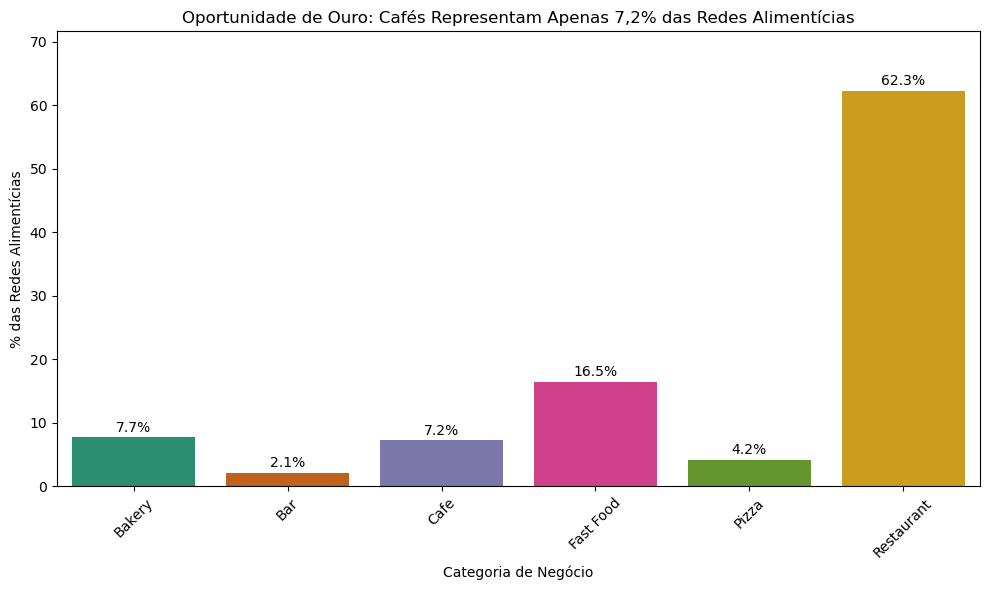

In [25]:
# Analisando os resultados com um gráfico de barras:

# Construindo um gráfico de barras para avaliar o resultado:


plt.figure(figsize=(10, 6))

# Criando o gráfico de barras com a paleta "Dark2"
ax = sns.barplot(
    x='tipo', 
    y='proporcao_percent', 
    data=de_rede_por_tipo, 
    palette='Dark2'
)

# adicionando os % de cada barra:

for p in ax.patches:

    ax.annotate(f'{p.get_height():.1f}%', 

                (p.get_x() + p.get_width() / 2., p.get_height()), 

                ha='center', va='center', 

                xytext=(0, 7), 

                textcoords='offset points')



plt.title('Oportunidade de Ouro: Cafés Representam Apenas 7,2% das Redes Alimentícias')

plt.xlabel('Categoria de Negócio')

plt.ylabel('% das Redes Alimentícias')

plt.xticks(rotation=45)

plt.ylim(0, de_rede_por_tipo['proporcao_percent'].max() * 1.15) # Para impedir que os dados menores fiquem dificeis de visualizar

plt.tight_layout()

plt.show()

conclusão:

Para estabelecimentos de rede:

- **Restaurantes** dominam (~62% das redes)
- **Fasts Food** em segundo lugar (~16%)
- **Bakery** em terceiro (~7,7%)
- **Cafés** tem presença menor nas redes (~7,2%), embora tenha presença maior nas redes que no mercado em geral.

Além disso, Essa análise revela que cafés são menos comuns em redes, o que significa:

- Menos competição de grandes franquias ✅

- Mais espaço para estabelecimentos independentes inovadores ✅

- Oportunidade para nossa cafeteria com garçons robôs ✅

Então tanto no mercado alimentício geral quanto em franquiados, cafés é um dos nichos menos saturados. O que pode significar uma boa sustentabilidade (geral) e crescimento (franquias)

## 3.4. O que caracteriza redes: Muitos estabelecimentos com um pequeno número de assentos ou poucos estabelecimentos com muitos assentos?

In [26]:
# Vamos filtrar os estabelecimentos independentes para comparar com os de rede
independentes = rest_data[rest_data['chain'] == False]

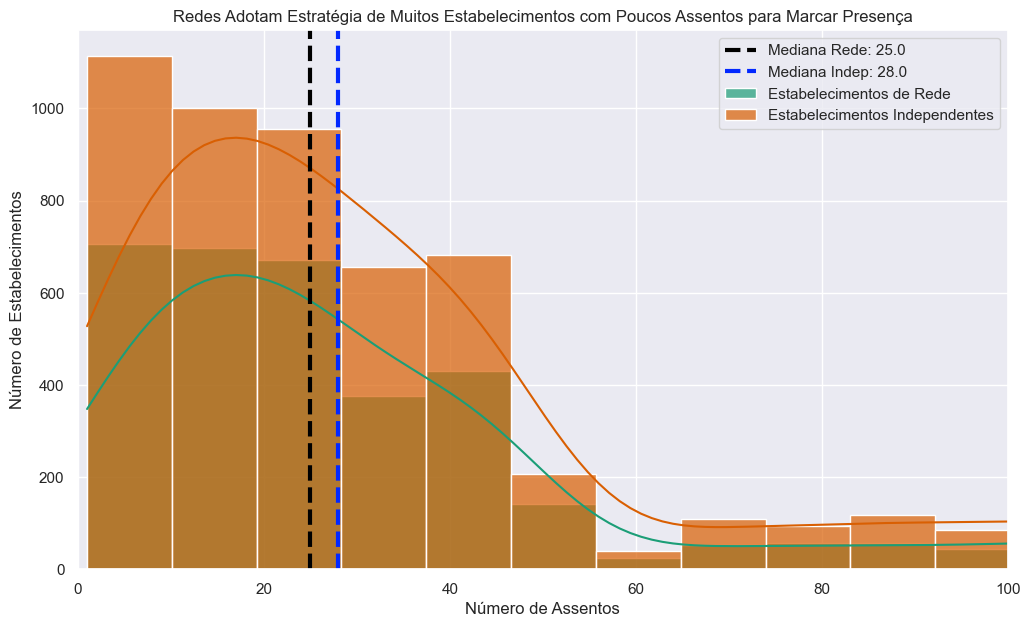

In [27]:
# Vamos fazer uma distribuição do número de assentos por estabelecimento de rede e independente:

sns.set_theme(style="darkgrid", palette="colorblind")
plt.figure(figsize=(12, 7))

mediana_rede = de_rede['number'].median()
mediana_ind = independentes['number'].median()

colors = sns.color_palette("Dark2", 2)

sns.histplot(de_rede['number'], bins=25, kde=True, alpha=0.7, color=colors[0], label='Estabelecimentos de Rede')
sns.histplot(independentes['number'], bins=25, kde=True, alpha=0.7, color=colors[1], label='Estabelecimentos Independentes')

plt.axvline(mediana_rede, color='#000000', linestyle='--', linewidth=3, label=f'Mediana Rede: {mediana_rede:.1f}')

plt.axvline(mediana_ind, color='#0228ff', linestyle='--', linewidth=3, label=f'Mediana Indep: {mediana_ind:.1f}')

plt.title('Redes Adotam Estratégia de Muitos Estabelecimentos com Poucos Assentos para Marcar Presença')
plt.xlabel('Número de Assentos')
plt.ylabel('Número de Estabelecimentos')
plt.xlim(0,100)
plt.legend()

plt.show()

conclusão:

Aparentemente, os estabelecimentos de rede parece ter uma média de assentos menor que os estabelecimentos independentes (metade dos estabelecimentos de rede utilizam até 25 assentos, diferença de 3 assentos para os estabelecimentos individuais), e a distribuição do número de assentos parece não ser normal. Vamos aceitar ou recusar isso através de um teste de hipóteses:

- $H_{0}$: A média de assentos entre os estabelecimentos de rede e independentes são iguais

- $H_{1}$: As média de assentos são diferente

In [28]:
# Vamos chamar a função teste_dados_continuos para comparar as duas médias, o nível de significância já está predefinido como 0.05 na função:

# argumentos:
h_0 = 'A média de assentos entre os estabelecimentos de rede e independentes são IGUAIS'
h_1 = 'A média de assentos entre os estabelecimentos de rede e independentes são DIFERENTES'
grupo_a = de_rede['number']
grupo_b = independentes['number']

# Chamada da função:
teste_dados_continuos(grupo_a, grupo_b, h_0, h_1)

Shapiro-Wilk (Grupo A): p=0.00000 | Normal: False
Anderson-Darling (Grupo B): Stat=509.234, Crit(5%)=0.752 | Normal: False
Decisão: Usando Mann-Whitney

--- Resultado do Teste de Hipótese ---
P-valor: 0.0000 | Alpha: 0.05
❌ Rejeitamos H0: A média de assentos entre os estabelecimentos de rede e independentes são DIFERENTES


C:\Users\Z4r4k1\AppData\Local\Temp\ipykernel_22332\4130949004.py:30: FutureWarning:

As of SciPy 1.17, users must choose a p-value calculation method by providing the `method` parameter. `method='interpolate'` interpolates the p-value from pre-calculated tables; `method` may also be an instance of `MonteCarloMethod` to approximate the p-value via Monte Carlo simulation. When `method` is specified, the result object will include a `pvalue` attribute and not attributes `critical_value`, `significance_level`, or `fit_result`. Beginning in 1.19.0, these other attributes will no longer be available, and a p-value will always be computed according to one of the available `method` options.



conclusão

- Constatamos o suspeitado: Os estabelecimentos de rede são marcados por conter menos assentos que os estabelecimentos independentes (são muitos estabelecimentos com poucos assentos) - A mediana indica que normalmente são 3 assentos a menos (25 contra 28 de estabelecimentos independentes)
- Isso quer dizer que Redes apostam em estratégia de eficiência operacional (poucos assentos para reduzir custos) e maior presença geográfica

## 3.5. Determinando o número médio de assentos para cada tipo de restaurante. Em média, qual tipo de restaurante tem o maior número de assentos?

C:\Users\Z4r4k1\AppData\Local\Temp\ipykernel_22332\3512667837.py:2: FutureWarning:



The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.


C:\Users\Z4r4k1\AppData\Local\Temp\ipykernel_22332\3512667837.py:2: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




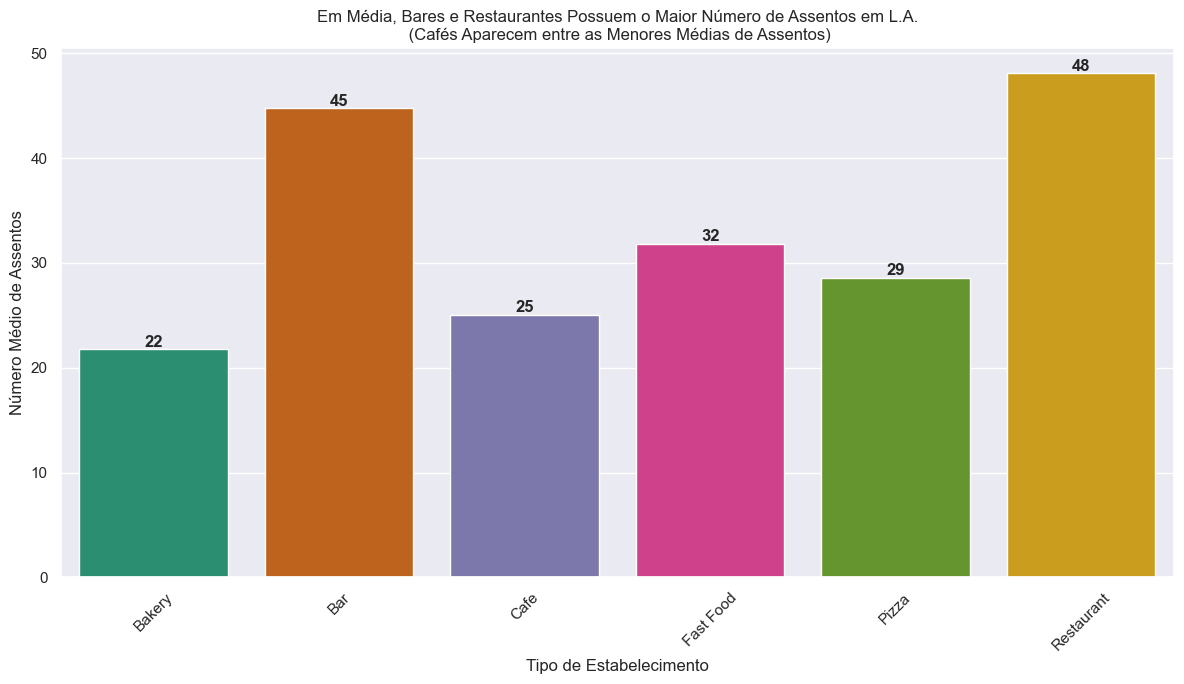

In [29]:
plt.figure(figsize=(12, 7))
ax = sns.barplot(x="object_type", y="number", data=rest_data, palette="Dark2", ci=None) # estimator=mean por padrão

# Adicionando valores nas barras

for p in ax.patches:
    ax.annotate(f'{p.get_height():.0f}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center',
                xytext=(0, 5),
                textcoords='offset points',
                fontsize=12, 
                fontweight='bold',
                zorder=10)


plt.title('Em Média, Bares e Restaurantes Possuem o Maior Número de Assentos em L.A.\n (Cafés Aparecem entre as Menores Médias de Assentos)')
plt.xlabel('Tipo de Estabelecimento')
plt.ylabel('Número Médio de Assentos')
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

## 3.6. Colocando os dados dos nomes das ruas da coluna 'address' em uma coluna separada.

In [30]:
# Aplicando a função extrair_rua ao dataframe rest_data, na coluna 'adress':
rest_data['street'] = rest_data['address'].apply(extrair_rua)

# Verificação
print(rest_data[['address', 'street']].head())
print(f"\nTotal de ruas únicas: {rest_data['street'].nunique()}")

                   address           street
0   3708 N EAGLE ROCK BLVD  EAGLE ROCK BLVD
1        100 WORLD WAY 120        WORLD WAY
2  6801 HOLLYWOOD BLVD 253   HOLLYWOOD BLVD
3       1814 W SUNSET BLVD      SUNSET BLVD
4       2100 ECHO PARK AVE    ECHO PARK AVE

Total de ruas únicas: 975


## 3.7. Construindo um gráfico das dez ruas com o maior número de restaurantes.

In [31]:
# Agrupando 'id' por 'street'
restaurant_per_street = rest_data.groupby('street')['id'].count().sort_values(ascending=False).reset_index()
top_10_streets = restaurant_per_street.head(10) # Pegando as top 10 ruas

C:\Users\Z4r4k1\AppData\Local\Temp\ipykernel_22332\6680878.py:8: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




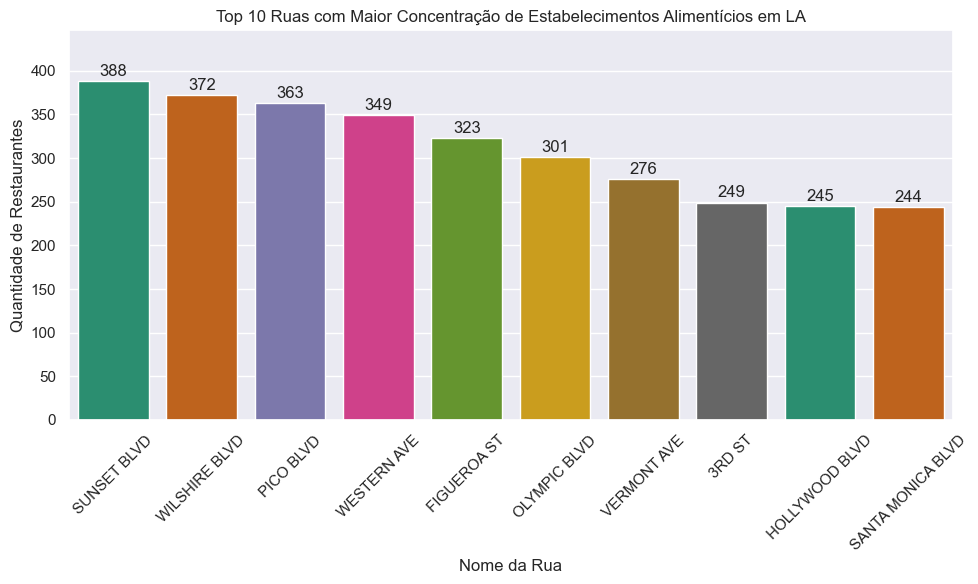

In [32]:
# Fazendo um gráfico de barras para visualizar o resultado:



plt.figure(figsize=(10, 6))

# Criando o gráfico de barras com a paleta "Dark2"
ax = sns.barplot(
    x='street', 
    y='id', 
    data=top_10_streets, 
    palette='Dark2'
)

# adicionando os % de cada barra:

for p in ax.patches:

    ax.annotate(f'{p.get_height():.0f}', 

                (p.get_x() + p.get_width() / 2., p.get_height()), 

                ha='center', va='center', 

                xytext=(0, 7), 

                textcoords='offset points')



plt.title('Top 10 Ruas com Maior Concentração de Estabelecimentos Alimentícios em LA')

plt.xlabel('Nome da Rua')

plt.ylabel('Quantidade de Restaurantes')

plt.xticks(rotation=45)

plt.ylim(0, top_10_streets['id'].max() * 1.15) # Para impedir que os dados menores fiquem dificeis de visualizar

plt.tight_layout()

plt.show()

conclusão:

- Sunset Blvd lidera com 388 estabelecimentos
- Wilshire Blvd em segundo com 372
- Pico Blvd em terceiro com 363
- Talvez seja uma boa avaliar o tráfego dessas regiões para avaliar se vale a pena correr esse alto risco de concorrência.

## 3.8. Encontrando o número de ruas que têm apenas um restaurante.

In [33]:
one_restaurant = restaurant_per_street[restaurant_per_street['id'] == 1]
streets_wich_one_restaurant = one_restaurant.shape[0]

print(f'Temos {streets_wich_one_restaurant} ruas com apenas 1 restaurante no total, isso equivale à {round((100*streets_wich_one_restaurant/975),2)}% do total de ruas com restaurantes\n(A grande maioria não tem sequer 2 estabelecimentos)')

Temos 646 ruas com apenas 1 restaurante no total, isso equivale à 66.26% do total de ruas com restaurantes
(A grande maioria não tem sequer 2 estabelecimentos)


conclusão: 

💡 Oportunidades estratégicas:
1. Mercado Pouco Saturado:

- 2/3 das ruas têm baixíssima competição
- Oportunidade de ser o primeiro ou segundo estabelecimento em centenas de ruas

2. Estratégia de Localização:

- Evitar as top 10 ruas (alta competição)
- Focar nas 646 ruas com apenas 1 estabelecimento
- Potencial para se tornar referência local nessas áreas

3. Vantagem Competitiva:

- Garçons robôs serão novidade absoluta nessas ruas
- Menor risco de cópia imediata da concorrência
- Possibilidade de fidelizar clientes antes da chegada de competidores

4. Custos Operacionais:

- Aluguel provavelmente mais barato que nas ruas movimentadas
- Menos pressão por localização premium

## 3.9. Observando a distribuição de número de assentos para as 10 ruas com mais restaurantes, quais tendências conseguimos notar?

In [34]:
# Selecionando os nomes unicos das ruas
streets = top_10_streets['street'].unique()
streets

array(['SUNSET BLVD', 'WILSHIRE BLVD', 'PICO BLVD', 'WESTERN AVE',
       'FIGUEROA ST', 'OLYMPIC BLVD', 'VERMONT AVE', '3RD ST',
       'HOLLYWOOD BLVD', 'SANTA MONICA BLVD'], dtype=object)

In [35]:
# Filtrando as linhas com as ruas com mais restaurantes em rest_data:
mais_restaurantes = rest_data[rest_data['street'].isin(streets)]
mais_restaurantes.head(3)

,id,object_name,address,chain,object_type,number,street
2,11788,STREET CHURROS,6801 HOLLYWOOD BLVD 253,False,Fast Food,20,HOLLYWOOD BLVD
3,11789,TRINITI ECHO PARK,1814 W SUNSET BLVD,False,Restaurant,22,SUNSET BLVD
10,11796,EL POLLO LOCO,5319 W SUNSET BLVD,True,Restaurant,38,SUNSET BLVD


- **Analisando a distribuição de assentos:**

***Distribuição de assentos por rua (violinplot/stripplot)***

C:\Users\Z4r4k1\AppData\Local\Temp\ipykernel_22332\1181742792.py:4: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.




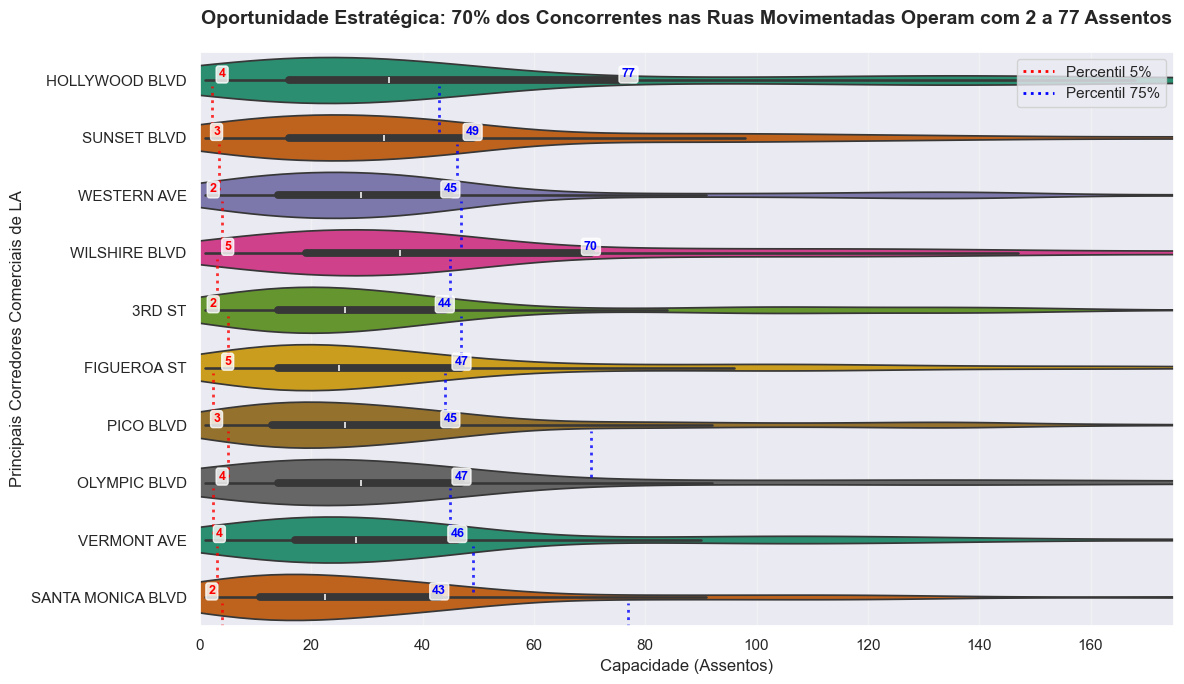

C:\Users\Z4r4k1\AppData\Local\Temp\ipykernel_22332\1181742792.py:64: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.




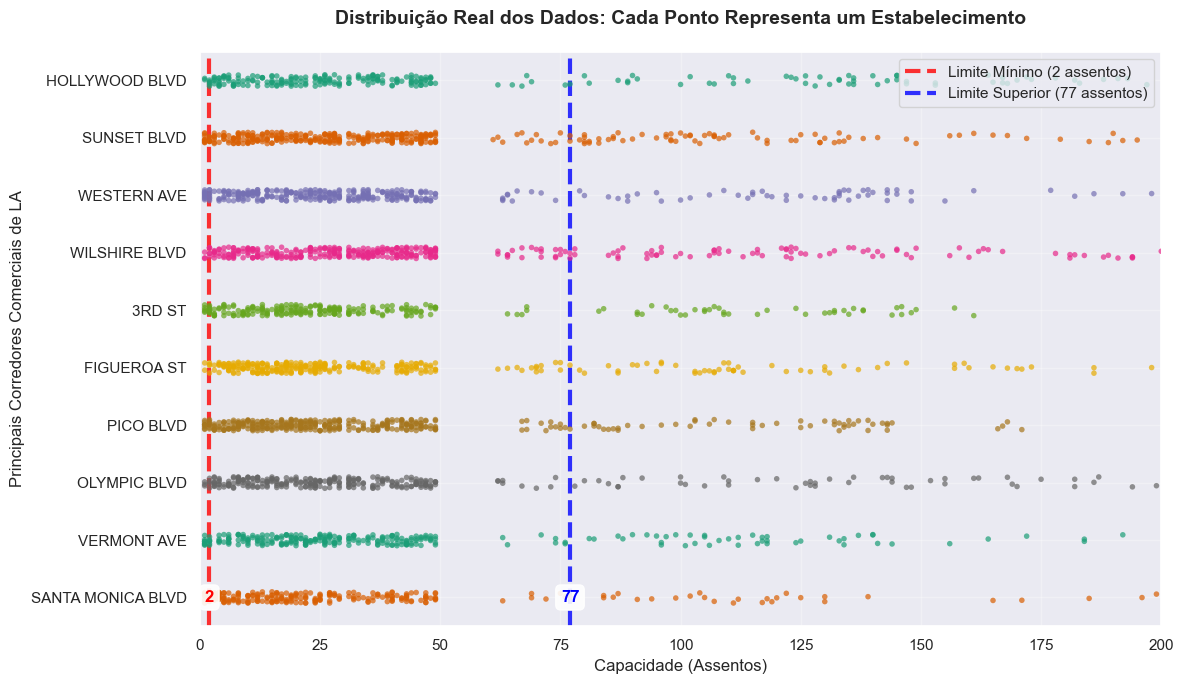

In [36]:
# violinplot com percentis 5% e 75%
plt.figure(figsize=(12,7))
sns.set_style('dark')
ax = sns.violinplot(
    x='number',
    y='street',
    data=mais_restaurantes,
    palette='Dark2',
    inner='box',
    orient='h'
)

# Adicionando linhas dos percentis 5% e 75% COM VALORES
for i, street in enumerate(mais_restaurantes['street'].unique()):
    street_data = mais_restaurantes[mais_restaurantes['street'] == street]['number']
    p5 = street_data.quantile(0.05)
    p75 = street_data.quantile(0.75)
    
    # Linhas verticais para os percentis
    ax.axvline(p5, ymin=(i-0.4)/len(mais_restaurantes['street'].unique()), 
               ymax=(i+0.4)/len(mais_restaurantes['street'].unique()), 
               color='red', linestyle=':', linewidth=2, alpha=0.8)
    ax.axvline(p75, ymin=(i-0.4)/len(mais_restaurantes['street'].unique()), 
               ymax=(i+0.4)/len(mais_restaurantes['street'].unique()), 
               color='blue', linestyle=':', linewidth=2, alpha=0.8)
    
    # ADICIONANDO OS VALORES nas linhas
    # Valor do percentil 5%
    ax.text(p5, i, f'{p5:.0f}', 
            ha='center', va='bottom', 
            color='red', fontweight='bold', fontsize=9,
            bbox=dict(boxstyle='round,pad=0.2', facecolor='white', alpha=0.8))
    
    # Valor do percentil 75%
    ax.text(p75, i, f'{p75:.0f}', 
            ha='center', va='bottom', 
            color='blue', fontweight='bold', fontsize=9,
            bbox=dict(boxstyle='round,pad=0.2', facecolor='white', alpha=0.8))

plt.title('Oportunidade Estratégica: 70% dos Concorrentes nas Ruas Movimentadas Operam com 2 a 77 Assentos', 
          fontsize=14, fontweight='bold', pad=20)
plt.xlabel('Capacidade (Assentos)', fontsize=12)
plt.ylabel('Principais Corredores Comerciais de LA', fontsize=12)
plt.xlim(0, 175)
plt.grid(True, alpha=0.3)

# Legenda atualizada
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], color='red', linestyle=':', linewidth=2, label='Percentil 5%'),
    Line2D([0], [0], color='blue', linestyle=':', linewidth=2, label='Percentil 75%')
]
ax.legend(handles=legend_elements, loc='upper right')

plt.tight_layout()

plt.show()

# ________________________________________________________________________________________________________________________________________

# stripplot com linhas verticais em 2 e 77
plt.figure(figsize=(12,7))
sns.set_style('dark')
ax = sns.stripplot(
    x='number',
    y='street',
    data=mais_restaurantes,
    palette='Dark2',
    orient='h',
    size=4,  # Controla o tamanho dos pontos
    alpha=0.7  # Adiciona transparência para ver sobreposições
)

# ADICIONANDO LINHAS VERTICAIS em 2 e 77
ax.axvline(2, color='red', linestyle='--', linewidth=3, alpha=0.8, label='Limite Mínimo (2 assentos)')
ax.axvline(77, color='blue', linestyle='--', linewidth=3, alpha=0.8, label='Limite Superior (77 assentos)')

# Adicionando texto nas linhas para destacar os valores
ax.text(2, len(mais_restaurantes['street'].unique())-1, '2', 
        ha='center', va='center', 
        color='red', fontweight='bold', fontsize=12,
        bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.9))

ax.text(77, len(mais_restaurantes['street'].unique())-1, '77', 
        ha='center', va='center', 
        color='blue', fontweight='bold', fontsize=12,
        bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.9))

plt.title('Distribuição Real dos Dados: Cada Ponto Representa um Estabelecimento', 
          fontsize=14, fontweight='bold', pad=20)
plt.xlabel('Capacidade (Assentos)', fontsize=12)
plt.ylabel('Principais Corredores Comerciais de LA', fontsize=12)
plt.xlim(0, 200)
plt.grid(True, alpha=0.3)

# Adicionando legenda
ax.legend(loc='upper right')

plt.tight_layout()

plt.show()

***média de assentos por rua (barplot):***

Como nenhuma distribuição por rua é normal (calda longa à direita), vamos representar os dados com a mediana

C:\Users\Z4r4k1\AppData\Local\Temp\ipykernel_22332\1398641711.py:3: FutureWarning:



The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.


C:\Users\Z4r4k1\AppData\Local\Temp\ipykernel_22332\1398641711.py:3: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




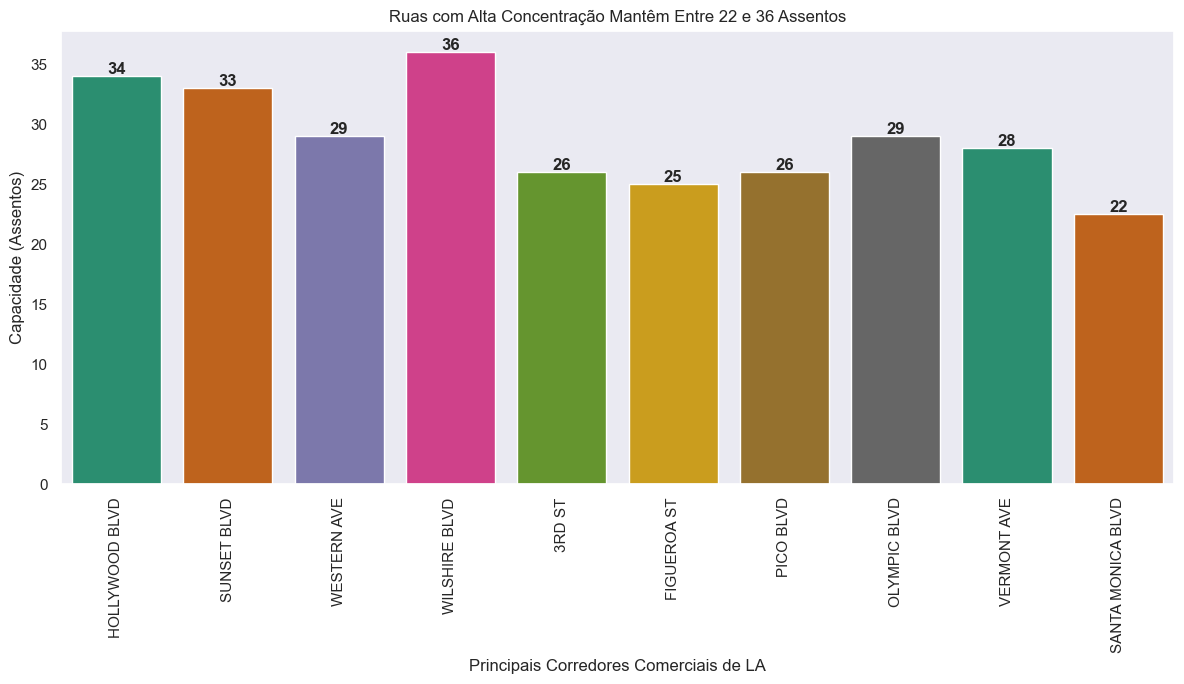

In [37]:
# Mediana de assentos por rua:
plt.figure(figsize=(12, 7))
ax = sns.barplot(x="street", y="number", data=mais_restaurantes, palette="Dark2", 
                 estimator=np.median, ci=None) 

for p in ax.patches:
    ax.annotate(f'{p.get_height():.0f}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center',
                xytext=(0, 5),
                textcoords='offset points',
                fontsize=12, 
                fontweight='bold',
                zorder=10)

plt.title('Ruas com Alta Concentração Mantêm Entre 22 e 36 Assentos')
plt.xlabel('Principais Corredores Comerciais de LA')  
plt.ylabel('Capacidade (Assentos)')  
plt.xticks(rotation=90)
plt.tight_layout()

plt.show()

conclusão:

70% dos estabelecimentos nas ruas mais movimentadas operam com 22-36 assentos - nossa cafeteria robótica se encaixa perfeitamente nesse padrão vencedor.

-  Mediana de 22-36 assentos nas principais ruas
-  Vantagem: Tamanho otimizado para eficiência operacional dos robôs

Diferencial Competitivo Sustentável

- Concorrentes: Operam no modelo tradicional de 22-36 assentos
- Nossa Vantagem: Mesma capacidade + tecnologia robótica = maior eficiência
- ROI: Menos garçons humanos, mais lucro por assento

## 3.10. conclusões e recomendações

🎯 Principais Descobertas do Mercado:
#### 1. Oportunidade no Nicho de Cafés
- Mercado pouco saturado: Cafés representam apenas 4,51% do setor alimentício em LA
- Baixa presença em redes: Apenas 7,2% das franquias são cafés
- Conclusão: Oceano azul com grande potencial de crescimento

#### 2. Dominância de Estabelecimentos Independentes
- 62% são independentes vs 38% de redes
- Espaço para inovação: Mercado receptivo a conceitos únicos
- Vantagem competitiva: Garçons robôs serão diferencial absoluto

#### 3. Estratégia de Capacidade Validada
- Redes operam com menos assentos: Mediana de 25 vs 28 (independentes)
- Faixa ideal identificada: 22-36 assentos nas ruas movimentadas
- Eficiência comprovada: Modelo de poucos assentos + alta rotatividade

#### 4. Oportunidades Geográficas Estratégicas
- 646 ruas (66,26%) têm apenas 1 estabelecimento
- Baixíssima competição: Oportunidade de pioneirismo
- Custos reduzidos: Aluguel mais barato que ruas saturadas

💡 Recomendações Estratégicas:
#### Para Localização:
- Evitar: Top 10 ruas (alta saturação, custos elevados)
- Focar: Ruas com 1-2 estabelecimentos existentes
- Priorizar: Áreas com potencial de crescimento residencial/comercial

#### Para Capacidade:
- Recomendação: 25-30 assentos
- Justificativa: Sweet spot entre eficiência operacional e receita
- Vantagem robótica: Mesma capacidade, menor custo operacional

#### Para Posicionamento:
- Diferencial: Tecnologia + experiência gastronômica
- Target: Mercado carente de inovação (4,51% de cafés)
- Sustentabilidade: Modelo replicável em outras ruas com baixa competição

### 📊 Validação dos Dados:
- Metodologia robusta: Testes estatísticos confirmaram diferenças significativas
- Dados limpos: Removidos 7 estabelecimentos com inconsistências
- Amostra representativa: 9.648 estabelecimentos analisados

🚀 Proposta de Valor:
"Nossa cafeteria com garçons robôs entrará em um mercado com apenas 4,51% de saturação de cafés, operando na faixa de capacidade comprovadamente eficiente (25-30 assentos), em localização estratégica com baixa competição, oferecendo inovação disruptiva em um setor dominado por estabelecimentos tradicionais."

# 4. Preparando uma apresentação

Presentation: <https://drive.google.com/file/d/1o4Dhy2eThrkLY8dN93oZHiWPfd5RnzzP/view?usp=sharing>